<a href="https://colab.research.google.com/github/c-mmonteiro/estudos/blob/main/Estudo_Minimos_Quadrados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudo de minimos quadrados



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import random

import time

plt.rcParams.update({
    "font.size": 16  # tamanho padrão de tudo
})

# 1. Classe do modelo de ajuste (SciPy)

#### Função para ajuste dos parâmetros

Partindo da função inicial onde se calculava o fator de correção:

$b(t) = y1 + y2*(t - t0)$

Utilizou-se a equação abaixo onde o fator de correção se torna implicito.

$t_c(t) = t + y1 + y2*(t - t0)$


In [2]:
class AjusteCurva():
  def __init__(self, t0):
    self.t0 = t0

  def func_ajuste(self, t, y1, y2):
    return t + y1 + y2*(t - self.t0)

  def fit(self, X, y):
    popt, pcov = curve_fit(self.func_ajuste, X, y)

    print(f'Resultado do fit:')

    self.y1 = popt[0]
    self.y2 = popt[1]
    self.popt = popt
    print(f'y1: {self.y1:.4f} \ny2: {self.y2:.5f}')

    #Desvio padrão de cada parâmetro
    perr = np.sqrt(np.diag(pcov))
    self.s_y1 = perr[0]
    self.s_y2 = perr[1]
    print(f'---\ns(y1) = {self.s_y1:.4f} \ns(y2) = {perr[1]:.5f}')

    #Coeficiente de Correlação
    self.r = pcov[1,0] / (perr[0]*perr[1])
    print(f'---\nr = {self.r:.3f}')

    #Devio padrão do erro (residuo)
    y_pred = self.func_ajuste(np.array(X), *self.popt)
    residuals = np.array(y) - y_pred
    self.std_pad_erro = np.sqrt(np.sum(residuals**2) / (len(y) - 2))
    print(f's(erro) = {self.std_pad_erro:.4f}')

    return self

  def predict(self, X):
    return self.func_ajuste(X, *self.popt)

In [3]:
t0 = 20
t_student = 2

# 2. Replicação do exemplo H3 do GUM-100

### Dados usados

Onde:
- t é a temperatura medida
- b é o fator de correção  ($b = t_R - t$)
- $t0 = 20°C$

In [4]:
b = [-0.171,
     -0.169,
     -0.166,
     -0.159,
     -0.164,
     -0.165,
     -0.156,
     -0.157,
     -0.159,
     -0.161,
     -0.160]

t = [21.521,
     22.012,
     22.512,
     23.003,
     23.507,
     23.999,
     24.513,
     25.002,
     25.503,
     26.010,
     26.511]
n = len(b)


In [5]:
tr = list(np.array(t) + np.array(b))

#### Define o modelo e calcula os parâmetros

In [6]:
model = AjusteCurva(20)
model.fit(t, tr)

Resultado do fit:
y1: -0.1712 
y2: 0.00218
---
s(y1) = 0.0029 
s(y2) = 0.00067
---
r = -0.930
s(erro) = 0.0035


#### Cálculo da Correção com Incerteza do Modelo

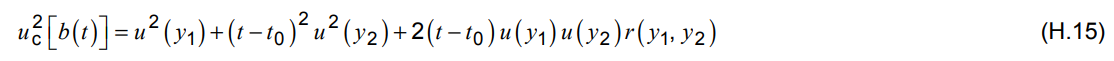

In [7]:
print(f'\n\nResultado da medição com Incerteza do Modelo:')
t_medido_x_test_list = 30

tr_pred = model.predict(30)

uc = np.sqrt(model.s_y1**2 + ((t_medido_x_test_list-model.t0)**2)*(model.s_y2**2) + 2*(t_medido_x_test_list-model.t0)*model.s_y1*model.s_y2*model.r)
print(f'uc[b({t_medido_x_test_list} °C)] = {uc:.4f} °C')

ip = uc*t_student
print(f'T = {(tr_pred):.4f} \u00B1 {ip:.4f} °C')



Resultado da medição com Incerteza do Modelo:
uc[b(30 °C)] = 0.0041 °C
T = 29.8506 ± 0.0083 °C


# 3. Aplicação com dados gerados

### Geração de dados

Onde:
- t é a temperatura medida
- b é o fator de correção, onde $t_R$ é a temperatura de referencia

$b = t_R - t$


- $t_0 = 20°C$

Ruido:
A geração dos dados foi feita com erro sistemático de -0,12 e ruido de medição com distribuição normal e desvio padrão de 0,1

In [8]:
erro_sistematico = -0.12
erro_aleatorio = 0.1

limite_inferior_modelo = 22
limite_superior_modelo = 27
passo_modelo = 0.25

limite_inferior_teste = 23
limite_superior_teste = 26
passo_teste = 0.1

In [9]:
t_ref_y_train_list = []
t_medido_x_train_list = []

for tr in np.arange(limite_inferior_modelo, limite_superior_modelo, passo_modelo):
  t = tr + random.gauss(erro_sistematico, erro_aleatorio)
  t_medido_x_train_list.append(t)
  t_ref_y_train_list.append(tr)


In [10]:
model_2 = AjusteCurva(t0)
model_2.fit(t_medido_x_train_list, t_ref_y_train_list)

Resultado do fit:
y1: 0.0451 
y2: 0.01723
---
s(y1) = 0.0616 
s(y2) = 0.01374
---
r = -0.949
s(erro) = 0.0870


## 3.1 Avaliando a incerteza por meio da propagação de incerteza

#### Cálculo da medição com a Incerteza da correção

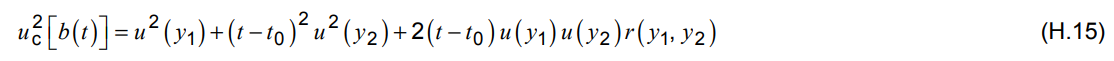

Ao final, combina a uc (incerteza combinada) do modelo com a u (incerteza padrão) da medição, obtendo $uc_f$ (incerteza combinada final)

$uc_f = \sqrt{uc(b)^2 + u(t)^2}$

Por último, multiplica a $uc_f$ pelo fator de t-Student para 95% com grau de liberdade de 22, uma vez que foram utilizadas 24 amostras para definição do y1 e y2.

Tempo gasto para calcular as incertezas: 0.0009 segundos


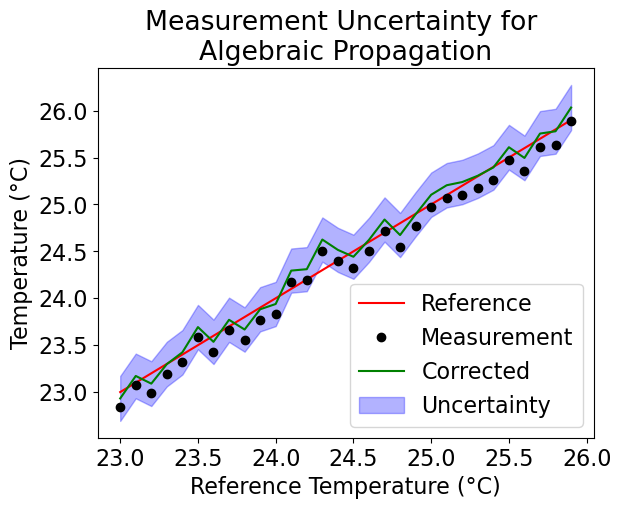

In [11]:
t_ref_test_list = np.arange(limite_inferior_teste, limite_superior_teste, passo_teste)
t_medido_x_test_list = []
t_corrigido_test_list = []
propagacao_mu_sup = []
propagacao_mu_inf = []

time_start = time.time()

for t_ref_test in t_ref_test_list:
  t_medido_x_test_list.append(t_ref_test + random.gauss(erro_sistematico, erro_aleatorio))

  uc = np.sqrt(model_2.s_y1**2 + ((t_medido_x_test_list[-1]-model_2.t0)**2)*(model_2.s_y2**2) + 2*(t_medido_x_test_list[-1]-model_2.t0)*model_2.s_y1*model_2.s_y2*model_2.r)

  ip = np.sqrt(uc**2 + erro_aleatorio**2)*2.31

  t_corrigido_test_list.append(model_2.predict(t_medido_x_test_list[-1]))
  propagacao_mu_sup.append(t_corrigido_test_list[-1] + ip)
  propagacao_mu_inf.append(t_corrigido_test_list[-1] - ip)

time_end = time.time()
tempo_propagation = time_end - time_start
print(f'Tempo gasto para calcular as incertezas: {time_end - time_start:.4f} segundos')

plt.plot(t_ref_test_list, t_ref_test_list, 'r-', label='Reference')
plt.plot(t_ref_test_list, t_medido_x_test_list, 'ko', label='Measurement')
plt.plot(t_ref_test_list, t_corrigido_test_list, 'g', label='Corrected')
plt.fill_between(t_ref_test_list, propagacao_mu_sup, propagacao_mu_inf, alpha=0.3, color='b', label='Uncertainty')
plt.legend()
plt.title('Measurement Uncertainty for \nAlgebraic Propagation')
plt.xlabel('Reference Temperature (°C)')
plt.ylabel('Temperature (°C)')
plt.savefig('fig_uc.pdf')

## 3.2 Avaliando a incerteza por Monte Carlo

In [12]:
num_simulacao = 1000000

Tempo de execução do Monte Carlo: 1.5969 segundos


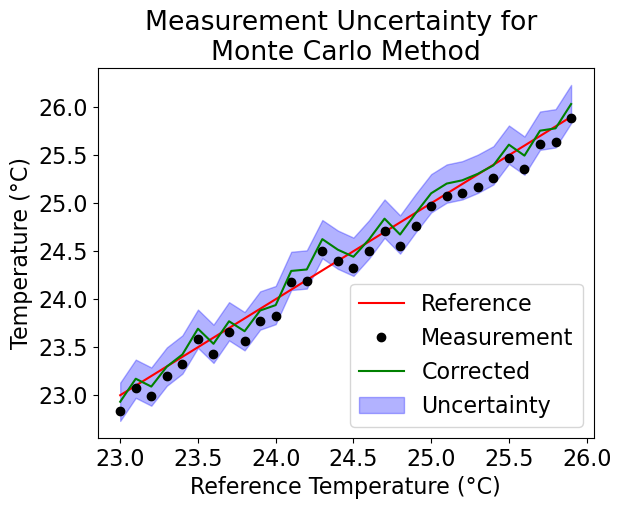

In [13]:
# ── Vectorised Monte Carlo ─────────────────────────────────────────────────
# Shape: (n_test, num_simulacao)
# All samples generated in one call → no Python loops.

start_time = time.time()

t_medido_x_test_array = np.array(t_medido_x_test_list)                                    # (n_test,)

mc_t_medido_x_test_array = np.random.normal(
    loc   = t_medido_x_test_array[:, None],                                 # broadcast over sims
    scale = erro_aleatorio,
    size  = (len(t_medido_x_test_array), num_simulacao),
)  # (n_test, num_simulacao)

# model_2.predict is: X + y1 + y2*(X - t0)  → fully vectorisable
mc_t_corrigido_test_array = model_2.predict(mc_t_medido_x_test_array)                                # (n_test, num_simulacao)

mc_t_corrigido_test_mean   = mc_t_corrigido_test_array.mean(axis=1)
mc_t_corrigido_test_std    = mc_t_corrigido_test_array.std(axis=1)
mc_t_corrigido_test_quantile = np.quantile(mc_t_corrigido_test_array, [0.025, 0.975], axis=1)  # (2, n_test)

mc_t_corrigido_test_mean_list = mc_t_corrigido_test_mean.tolist()
mc_t_corrigido_test_std_list  = mc_t_corrigido_test_std.tolist()
mc_mu_sup        = mc_t_corrigido_test_quantile[1].tolist()
mc_mu_inf        = mc_t_corrigido_test_quantile[0].tolist()

end_time = time.time()
tempo_mc = end_time - start_time
print(f'Tempo de execução do Monte Carlo: {end_time - start_time:.4f} segundos')

plt.plot(t_ref_test_list, t_ref_test_list, 'r-', label='Reference')
plt.plot(t_ref_test_list, t_medido_x_test_list, 'ko', label='Measurement')
plt.plot(t_ref_test_list, mc_t_corrigido_test_mean_list, 'g', label='Corrected')
plt.fill_between(t_ref_test_list, mc_mu_sup, mc_mu_inf, alpha=0.3, color='b', label='Uncertainty')
#plt.errorbar(t_ref, mc_temp_simulation, mc_std_pad, fmt='o', color='b', ecolor='lightgray', elinewidth=3, capsize=5)
plt.legend()
plt.title('Measurement Uncertainty for \nMonte Carlo Method')
plt.xlabel('Reference Temperature (°C)')
plt.ylabel('Temperature (°C)')
plt.savefig('fig_mc.pdf')


## 3.3 Aplicação da Predição Conforme

Considerando como entrada do modelo o valor de leitura e como saída as diversas possibilidades simuladas por Monte Carlo, definir o indice de conformidade a partir destes dados.

#### Predição Conforme Manual (Split CP — sem bibliotecas)

Calibração com n = 20000000 pontos
Quantil conforme q̂ (α=0.05):  0.2597 °C
Cobertura empírica no conjunto de teste: 96.7 %  (alvo ≥ 95 %)
Tempo total (calibração + teste): 5.4598 segundos
Tempo gasto apenas na calibração: 5.4596 segundos
Tempo gasto apenas no teste: 0.0002 segundos


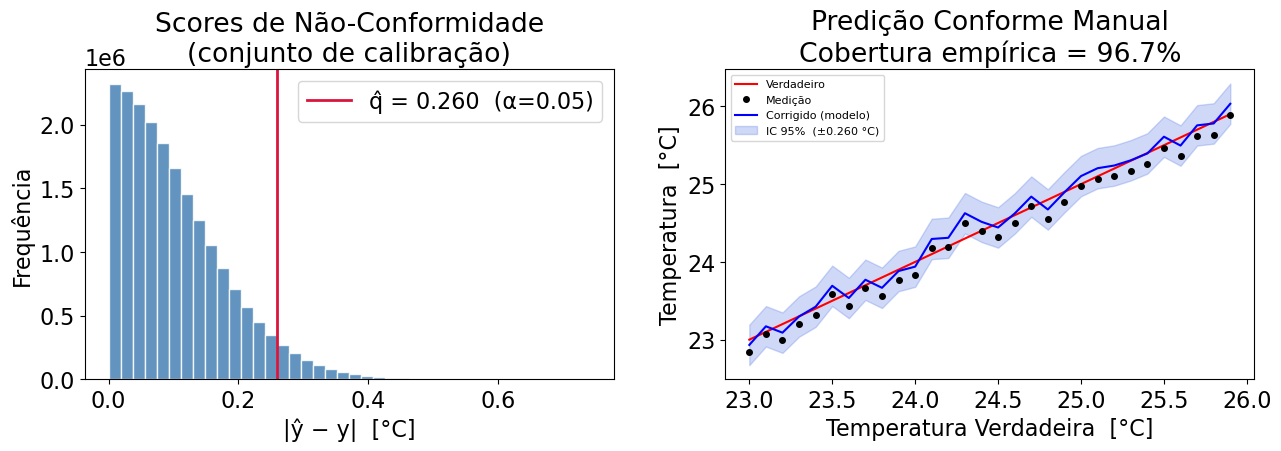

In [14]:
import numpy as np
import matplotlib.pyplot as plt

start_time = time.time()
# 1. Gerar amostras de calibração (t_i, tr_i) por MC
# ── Vectorised Monte Carlo para calibração conforme ───────────────────────
t_medido_x_train_array  = np.array(t_medido_x_train_list)    # (N,)
t_ref_y_train_array = np.array(t_ref_y_train_list)   # (N,)


# 1.1. Incerteza combinada por ponto de calibração (sem loop)
#uc_model = np.sqrt(
#    model_2.s_y1**2
#    + (t_arr - model_2.t0)**2 * model_2.s_y2**2
#    + 2*(t_arr - model_2.t0)*model_2.s_y1*model_2.s_y2*model_2.r
#)
#uc_total = np.sqrt(uc_model**2 + erro_aleatorio**2)   # (N,)
cp_uc_input = np.repeat(erro_aleatorio, len(t_medido_x_train_array))   # (N,)

# 1.2. Repetir cada ponto num_simulacao vezes → (N*num_simulacao,)
t_medido_x_train_array_rep  = np.repeat(t_medido_x_train_array,    num_simulacao)
t_ref_y_train_array_rep = np.repeat(t_ref_y_train_array,   num_simulacao)
cp_uc_input_rep = np.repeat(cp_uc_input, num_simulacao)


# 1.3. Amostras ruidosas + predição — tudo em uma chamada
t_medido_mc_x_train_array_rep  = np.random.normal(t_medido_x_train_array_rep, cp_uc_input_rep)              # (N*num_simulacao,)
t_corrigido_mc_x_train_array_rep   = model_2.predict(t_medido_mc_x_train_array_rep)                       # (N*num_simulacao,)

# Manter como listas para compatibilidade com células seguintes
t_medido_x_train_list         = t_medido_x_train_array_rep.tolist()
t_ref_y_train_list              = t_ref_y_train_array_rep.tolist()
t_corrigido_mc_x_train_list = t_corrigido_mc_x_train_array_rep.tolist()

# 2. Inicia calibração conforme manual usando os dados gerados

# ─── 1. Dados de Calibração ────────────────────────────────────────────────
#  X_calib : leitura do sensor  (entrada do modelo)
#  y_calib : temperatura simulada por Monte Carlo (saída alvo)
X_calib = np.array(t_medido_x_train_list)    # shape (N,)
y_calib = np.array(t_corrigido_mc_x_train_list)  # shape (N,)

# ─── 2. Scores de Não-Conformidade ────────────────────────────────────────
#  Score padrão para regressão:  s_i = |ŷ_i - y_i|
#y_calib_pred = np.array([model_2.predict(x) for x in X_calib])
#scores = np.abs(y_calib_pred - y_calib)
scores = np.abs(np.array(t_corrigido_mc_x_train_list) - np.array(t_ref_y_train_list))

# ─── 3. Quantil Conforme (correção de amostra finita) ─────────────────────
#  Para garantir cobertura marginal (1-α):
#
#    q̂ = score no índice ⌈(n+1)(1-α)⌉/n  da distribuição ordenada,
#         clampado ao intervalo [0, 1] antes de usar np.quantile
#
alpha = 0.05          # nível de erro desejado  →  95 % de cobertura
n     = len(scores)
level = min(1.0, np.ceil((n + 1) * (1 - alpha)) / n)   # ≥ (1-α) com correção

q_hat = np.quantile(scores, level)

middle_time = time.time()

# ─── 4. Predição sobre os pontos de teste ─────────────────────────────────
X_test = np.array(t_medido_x_test_list)
y_cp_pred     = np.array([model_2.predict(x) for x in X_test])
y_cp_lower    = y_cp_pred - q_hat
y_cp_upper    = y_cp_pred + q_hat

end_time = time.time()

# ─── 5. Cobertura Empírica ─────────────────────────────────────────────────
y_true = np.array(t_ref_test_list)   # temperaturas verdadeiras de referência
covered  = np.sum((y_true >= y_cp_lower) & (y_true <= y_cp_upper))
coverage = covered / len(y_true)




print(f"Calibração com n = {n} pontos")
print(f"Quantil conforme q̂ (α={alpha}):  {q_hat:.4f} °C")

print(f"Cobertura empírica no conjunto de teste: {coverage*100:.1f} %  "
      f"(alvo ≥ {(1-alpha)*100:.0f} %)")

tempo_cp_calib = middle_time - start_time
tempo_cp_inferencia = end_time - middle_time
print(f'Tempo total (calibração + teste): {end_time - start_time:.4f} segundos')
print(f'Tempo gasto apenas na calibração: {middle_time - start_time:.4f} segundos')
print(f'Tempo gasto apenas no teste: {end_time - middle_time:.4f} segundos')

# ─── 6. Visualização ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# — Distribuição dos scores de calibração —
ax = axes[0]
ax.hist(scores, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(q_hat, color='crimson', linewidth=2,
           label=f'q̂ = {q_hat:.3f}  (α={alpha})')
ax.set_title('Scores de Não-Conformidade\n(conjunto de calibração)')
ax.set_xlabel('|ŷ − y|  [°C]')
ax.set_ylabel('Frequência')
ax.legend()

# — Intervalos de predição sobre o conjunto de teste —
ax = axes[1]
ax.plot(t_ref_test_list, t_ref_test_list, 'r-', label='Verdadeiro', linewidth=1.5)
ax.plot(t_ref_test_list, t_medido_x_test_list, 'ko', markersize=4, label='Medição')
ax.plot(t_ref_test_list, y_cp_pred, 'b-', linewidth=1.5, label='Corrigido (modelo)')
ax.fill_between(t_ref_test_list, y_cp_lower, y_cp_upper,
                alpha=0.25, color='royalblue',
                label=f'IC {(1-alpha)*100:.0f}%  (±{q_hat:.3f} °C)')
ax.set_title(f'Predição Conforme Manual\nCobertura empírica = {coverage*100:.1f}%')
ax.set_xlabel('Temperatura Verdadeira  [°C]')
ax.set_ylabel('Temperatura  [°C]')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


#### Gráfico dos dados gerados para calibração

/tmp/ipykernel_39378/4093338438.py:8: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('fig_cp_calib_samples.png')
/home/carlos-monteiro/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


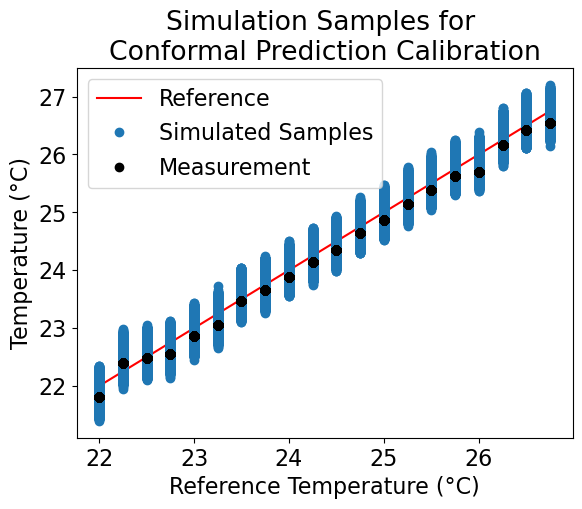

In [15]:
plt.plot(t_ref_y_train_list, t_ref_y_train_list, 'r-', label='Reference')
plt.plot(t_ref_y_train_list, t_corrigido_mc_x_train_array_rep, 'o', label='Simulated Samples')
plt.plot(t_ref_y_train_list, t_medido_x_train_list, 'ko', label='Measurement')
plt.legend()
plt.title('Simulation Samples for \nConformal Prediction Calibration')
plt.xlabel('Reference Temperature (°C)')
plt.ylabel('Temperature (°C)')
plt.savefig('fig_cp_calib_samples.png')

#### Gráfico da incerteza pelo CP

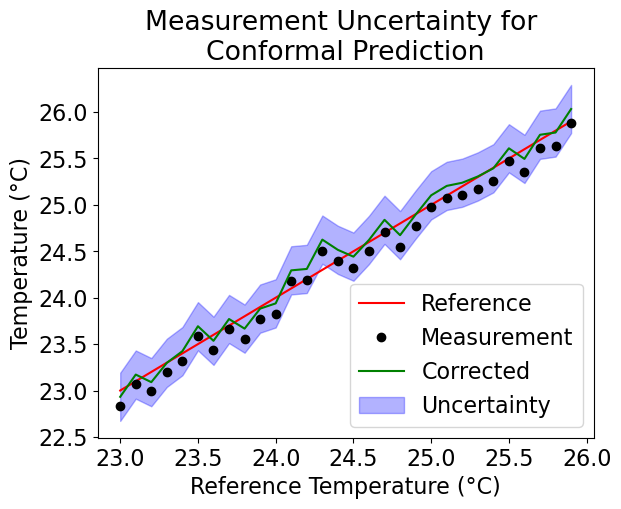

In [16]:
plt.plot(t_ref_test_list, t_ref_test_list, 'r-', label='Reference')
plt.plot(t_ref_test_list, t_medido_x_test_list, 'ko', label='Measurement')
plt.plot(t_ref_test_list, y_cp_pred, 'g', label='Corrected')
plt.fill_between(t_ref_test_list, y_cp_lower, y_cp_upper, alpha=0.3, color='b', label='Uncertainty')
#plt.errorbar(t_ref, mc_temp_simulation, mc_std_pad, fmt='o', color='b', ecolor='lightgray', elinewidth=3, capsize=5)
plt.legend()
plt.title('Measurement Uncertainty for \nConformal Prediction')
plt.xlabel('Reference Temperature (°C)')
plt.ylabel('Temperature (°C)')
plt.savefig('fig_cp.pdf')

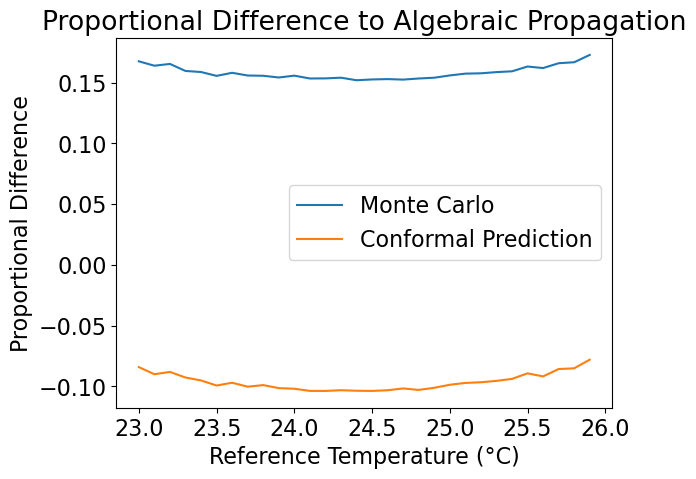

In [17]:
diff_prop_mc = ((np.array(propagacao_mu_sup) - np.array(propagacao_mu_inf)) - (np.array(mc_mu_sup) - np.array(mc_mu_inf)))/(np.array(propagacao_mu_sup) - np.array(propagacao_mu_inf))
diff_prop_cp = ((np.array(propagacao_mu_sup) - np.array(propagacao_mu_inf)) - (np.array(y_cp_upper) - np.array(y_cp_lower)))/(np.array(propagacao_mu_sup) - np.array(propagacao_mu_inf))

plt.plot(t_ref_test_list, diff_prop_mc, label='Monte Carlo')
plt.plot(t_ref_test_list, diff_prop_cp, label='Conformal Prediction')
plt.legend()
plt.title('Proportional Difference to Algebraic Propagation')
plt.xlabel('Reference Temperature (°C)')
plt.ylabel('Proportional Difference')
plt.savefig('fig_compar.pdf')

#### Gráfico com todas as IM

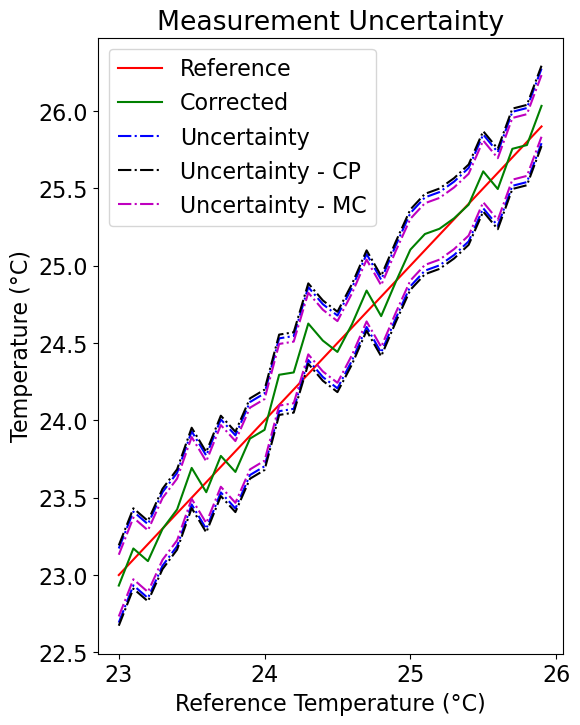

In [40]:
plt.figure(figsize=(6, 8))

plt.plot(t_ref_test_list, t_ref_test_list, 'r', label='Reference')
#plt.plot(t_ref_test_list, t_medido_x_test_list, 'ko', label='Measurement')
plt.plot(t_ref_test_list, mc_t_corrigido_test_mean_list, 'g', label='Corrected')

plt.plot(t_ref_test_list, propagacao_mu_sup, 'b-.', label='Uncertainty')
plt.plot(t_ref_test_list, propagacao_mu_inf, 'b-.')

plt.plot(t_ref_test_list, y_cp_upper, 'k-.', label='Uncertainty - CP')
plt.plot(t_ref_test_list, y_cp_lower, 'k-.')

plt.plot(t_ref_test_list, mc_mu_sup, 'm-.', label='Uncertainty - MC')
plt.plot(t_ref_test_list, mc_mu_inf, 'm-.')






#plt.errorbar(t_ref, mc_temp_simulation, mc_std_pad, fmt='o', color='b', ecolor='lightgray', elinewidth=3, capsize=5)
plt.legend()
plt.title('Measurement Uncertainty')
plt.xlabel('Reference Temperature (°C)')
plt.ylabel('Temperature (°C)')
plt.savefig('fig_all.pdf', bbox_inches='tight')

#### Tabela tempos

In [19]:
print(f'   Modelo       |  Tempo (s)  ')
print(f'----------------|--------------')
print(f'Propagação      | {tempo_propagation:.6f} ')
print(f'Monte Carlo     | {tempo_mc:.6f} ')
print(f'CP - Calibração | {tempo_cp_calib:.6f} ')
print(f'CP - Inferência | {tempo_cp_inferencia:.6f} ')

   Modelo       |  Tempo (s)  
----------------|--------------
Propagação      | 0.000890 
Monte Carlo     | 1.596891 
CP - Calibração | 5.459623 
CP - Inferência | 0.000196 


#### Computa o erro absoluto

In [20]:
erro_mc_prop = np.abs((np.array(mc_mu_sup) - np.array(mc_mu_inf))/2 - (np.array(propagacao_mu_sup) - np.array(propagacao_mu_inf))/2)
erro_cp_prop = np.abs((np.array(y_cp_upper) - np.array(y_cp_lower))/2 - (np.array(propagacao_mu_sup) - np.array(propagacao_mu_inf))/2)
erro_cp_mc = np.abs((np.array(y_cp_upper) - np.array(y_cp_lower))/2 - (np.array(mc_mu_sup) - np.array(mc_mu_inf))/2)

print(f'erro absoluto do CP:')
print(f'  Métrica   |   MC     | Propagation')
print(f'   Mean     | {np.mean(erro_cp_mc):.6f} | {np.mean(erro_cp_prop):.6f}')
print(f'   Std      | {np.std(erro_cp_mc):.6f} | {np.std(erro_cp_prop):.6f}')

print(f'\n MC / Propagation \nMean: {np.mean(erro_mc_prop):.6f} \nStd:  {np.std(erro_mc_prop):.6f}')




erro absoluto do CP:
  Métrica   |   MC     | Propagation
   Mean     | 0.060295 | 0.022773
   Std      | 0.000172 | 0.001497

 MC / Propagation 
Mean: 0.037522 
Std:  0.001498
